מגיש : גיא ולצמן     

2 Dataset Selection

2.1 Requirements

The "Video Game Sales with Ratings" dataset meets the following criteria:

Tabular Data: The file is provided in CSV format, which constitutes structured tabular data.  

At least 1000 rows: The dataset contains over 16,000 rows, with each row representing a single video game.  

At least 10 columns: The dataset consists of 16 distinct columns.  

Combination of numeric, time, and categorical variables:

Numeric variables: Sales data in millions of copies across different regions (NA_Sales, EU_Sales, Global_Sales), critic scores (Critic_Score), and user scores (User_Score).

Time variables: The release year of the game (Year_of_Release).

Categorical variables: Gaming platform (Platform), game genre (Genre), publishing company (Publisher), and age rating (Rating).

2.2 Data Source Description

Data Source: The dataset was obtained from Kaggle, titled "Video Game Sales with Ratings".  

Purpose of Collection: To track, analyze, and document the commercial and critical success of the global video game industry.  

Collecting Entity: The raw data was originally aggregated by VGChartz (for sales figures) and Metacritic (for review scores). The unified dataset was created by Kaggle users through web scraping from these primary sources.  

Connection to Personal Domain Knowledge: I have a deep personal interest and extensive experience in the gaming world, specifically with role-playing games (RPGs), roguelites, and heavily modded multiplayer environments. My hands-on experience with underlying game mechanics—such as character movement attributes and stat scaling—as well as community dynamics like multiplayer server management, allows for a deeper contextual analysis of this data. For example, I can investigate whether specific genres like RPGs demonstrate longer sales lifespans or analyze the discrepancies between user sentiment and official critic scores.  

Note on Missing Information: The dataset focuses exclusively on the sales of full physical and digital copies. It completely lacks data on modern economic models such as Free-to-Play games, microtransaction revenues, or expansion (DLC) sales. This omission is a significant insight regarding the dataset's limitations, as it measures success through a traditional economic model that does not accurately represent the industry's total revenue streams today.

3 Meta-Analysis of the Data

3.1 File Analysis

File Size: The file size is approximately 1.44 MB.  

Format: The dataset is provided as a Comma-Separated Values (CSV) file.  

Creation Date: The dataset was aggregated several years ago, with the majority of its records updated up to December 2016.  

Purpose of the Data: The data is intended for statistical examination of trends within the video game industry, such as platform popularity over time and the correlation between critic reviews and commercial success.  

3.2 Data Structure

Number of Rows and Columns: The dataset contains exactly 16,719 rows and 16 columns.  

Column Names: The column names are highly intuitive and make logical sense (e.g., Name, NA_Sales, Critic_Score). This indicates that the dataset creator pre-organized and appropriately tagged the data to facilitate the exploratory analysis process.  

Data Types: The dataset contains various data types, including strings (objects) for names and genres, and floating-point numbers for sales and scores. A key insight here is that some columns will require type conversion; for instance, 'Year_of_Release' should be converted to an integer or datetime format to properly conduct time-series analysis.  

Discussion (Bias and Collection): The data was originally collected for operational purposes by news and review websites, but was aggregated into this table for research purposes. Potential biases include survivorship bias, where smaller, unsuccessful games are entirely absent from the database. Additionally, there is a strong bias toward physical copy sales over digital sales, which are not always transparently reported by publishers. Finally, there is a historical bias, as very old games did not receive computerized critic or user ratings in real-time, creating a structural lack of data in those specific rows.  

4 Data Quality and Completeness

4.1 Missing Data

Extent of Missing Data: The columns suffering from the most significant missing data are User_Count (54.6%), Critic_Count (51.3%), and Critic_Score (51.3%). Rating, User_Score, and Developer also lack around 40% of their respective data.  

Missing Data Pattern: The missing data is not random but follows a structural pattern. Very old games (pre-dating the internet and review aggregator sites) and niche indie games that did not receive broad media coverage naturally lack review scores.  

Imputation Strategy: Imputing missing scores with a global average would distort the data. A better approach would be to impute missing scores using the median of the corresponding game genre, or simply leave them as missing values (NaN) when conducting analyses focused strictly on sales.  

4.2 Duplicates

Full Duplicates: There are exactly 0 full duplicates (completely identical rows) in the dataset.  

Partial Duplicates: There are 5 partial duplicates where the exact same game Name appears more than once under the exact same Platform.  

Conclusions and Treatment: These partial duplicates are likely due to data entry errors or split regional releases. It is recommended to drop these duplicates entirely to prevent the double-counting of sales figures.  

4.3 Suspicious Values

Placeholder Values: In the User_Score column, there are 2,425 values containing the string "tbd" (To Be Determined). These act as placeholders for games that have not yet accumulated enough user reviews to form an aggregate score.  

Impossible/Unlikely Values: The maximum Year_of_Release is 2020, despite the dataset primarily being updated only through 2016. These outlier years likely represent games that were announced in advance but later delayed or cancelled, or they are simply data entry errors.  

Insights for Cleaning: These values require data cleaning. Specifically, the "tbd" strings must be replaced with null values (NaN), and the User_Score column must be cast to a numeric data type so that mathematical operations can be performed on it later.  

4.4 Cardinality

Zero Variance Columns: There are no columns with a single unique value or zero variance.  

High and Low Cardinality: As expected, the 'Name' column possesses the highest cardinality with 11,562 unique values. Conversely, categorical columns like Platform (31), Genre (12), and Rating (8) have low cardinality, which allows for convenient grouping and cross-sectional statistical analysis based on these categories.

5 Univariate Analysis

5.1 Numeric Variables (Focusing on Global_Sales)

Central Metrics: We calculated the mean, median, standard deviation, minimum, maximum, quantiles, IQR, and MAD for global sales.  

Bias and Distribution: The data is heavily right-skewed (positive skewness). This indicates that the vast majority of games sell a relatively small number of copies, while a tiny fraction of mega-hits (e.g., Wii Sports) sell tens of millions of copies, artificially pulling the mean much higher than the median.  

Outliers: Three distinct methods were applied to detect 1D outliers:  

Z-Score: Detected the fewest outliers, as the extreme values inflate the standard deviation, allowing some high-selling games to hide within the standard deviation boundaries.  

IQR Rule: Detected a massive number of outliers because it strictly defines anything beyond 1.5 times the IQR as an anomaly. In the gaming industry, hits are mathematically treated as outliers.  

Modified Z-Score (using MAD): Provided a robust measurement against extreme outliers by relying on the median. This method successfully flagged the "blockbuster" games without letting their high sales corrupt the baseline metric.  

5.2 Categorical Variables (Focusing on Genre)

Frequencies: The most frequent category (Mode) is the "Action" genre, which represents roughly 20% of the entire dataset.  

Top K Variables: The top 3 genres combined (typically Action, Sports, and Misc) account for a highly significant percentage of the overall market.  

P% Representation: To describe 80% of the dataset, we need approximately 7 different genres out of the 12 available.  

Rare Categories: Genres such as "Puzzle" or "Strategy" account for a very small fraction of total releases. While they are informative regarding historical trends (e.g., PC strategy games), they might act as noise in certain predictive models and could potentially be grouped into an "Other" category for machine learning purposes.  

Discussion

Do the central metrics represent the data well? For numeric columns like global sales, the mean is a very poor representation of the dataset due to extreme rightward skew. The median is a much more reliable metric for understanding the commercial performance of a "typical" game. For categorical data, the mode effectively highlights the industry's focus on high-action entertainment.



6 Correlations and Relationships

6.1 Numeric-Numeric Correlations

Methodology Differences:

Pearson: Measures the linear relationship between two continuous variables. It is highly sensitive to outliers, which we know exist in our heavily right-skewed sales data.  

Spearman: A non-parametric rank correlation. It assesses monotonic relationships and is much more robust against outliers because it evaluates the rank order of the values rather than the raw sales figures.  

Kendall: Also a rank-based correlation, but it measures the ordinal association based on concordant and discordant pairs. It is highly effective for data with many tied ranks.  

Conclusions on Correlation: Based on the correlation matrices, there is a moderate positive correlation between Critic_Score and Global_Sales. However, the correlation between User_Score and Global_Sales is significantly weaker. This implies that professional critical acclaim has a stronger association with a game's commercial success than the average player's rating.  

6.2 Categorical-Categorical and Binning

Binning: We applied binning to the continuous Global_Sales variable, converting it into a categorical variable with three equal-sized quantiles (Low, Medium, High).  

Frequency Tables (Cross-tabulation): By creating a cross-tabulation between 'Genre' and the new 'Sales_Category', we successfully linked categorical and numeric concepts. The data reveals that the "Action" and "Shooter" genres have a disproportionately higher presence in the "High" sales bin compared to niche genres like "Puzzle" or "Strategy".  

6.3 Visualizations and Insights

Scatterplot (Critic Score vs. Global Sales): The graph shows a dense clustering of games with low sales regardless of their score. However, the few outlier games that achieve massive global sales almost exclusively possess high critic scores (typically 80+).  

Histogram (Critic Scores): The distribution of critic scores is roughly normal but slightly left-skewed, centering around a score of 70. This indicates that professional reviewers tend to grade somewhat generously, rarely utilizing the lower end of the scoring spectrum.  

Barchart (Games per Genre): Visually confirms the univariate analysis, clearly highlighting Action and Sports as the most saturated markets in terms of sheer volume of releases.  

Boxplot (Scores across Genres): Reveals that Role-Playing and Strategy games often maintain a higher median critic score and a tighter interquartile range compared to Action games, which display massive variance and numerous low-scoring outliers.  

Violin Plot (Sales by Genre): By filtering out the massive outliers (sales < 2M), the plot shows the dense concentration of sales near the zero mark across all genres. This emphasizes the right-skewed nature of the industry, where most games do not achieve mainstream commercial success.  

Pie Chart (Top Platforms): Illustrates the market dominance of historical platforms like the PS2 and DS in terms of the pure volume of game releases.  

Pairplot: Provides a rapid visual summary of all numeric interactions, confirming the linear trends between scores and visualizing the lack of correlation between the release year and the ultimate success of a game.  

Heatmap: The Spearman heatmap clearly visualizes the correlation strength using color gradients, confirming the moderate relationship between critic scores and sales, and validating our earlier correlation calculations.

7 Index Analysis

Is the index unique? Yes. The current index of the DataFrame is a default Pandas RangeIndex. It is entirely unique, meaning every row (game) in our dataset is assigned a distinct integer ID without any overlapping or duplicate index values.

Is it time-based? No, the index is purely numeric, not time-based (DatetimeIndex). While the dataset does contain a time variable column (Year_of_Release), the index itself does not represent a chronological timeline.

Is it sorted? Yes, the numeric index is perfectly sorted in ascending order (monotonic increasing from 0 to 16,718). Furthermore, the dataset itself is fundamentally pre-sorted by Global_Sales in descending order, meaning the most commercially successful games appear at the very top of the index.

7.2 Does the analysis change over time?

The raw dataset we are analyzing is a static snapshot, primarily updated only through December 2016. Because the file itself is static, our specific mathematical analysis (the mean, correlations, outliers) does not change over time.

However, conceptually, the video game industry is highly temporal and dynamic. If this dataset were directly connected to a live database today, the entire analysis would constantly shift. Market trends change, new platforms are released, and the dominance of specific genres fluctuates across different gaming eras.

8 Insights and Data Story  

8.1 Detailed Summary This exploratory data analysis (EDA) comprehensively examined the "Video Game Sales with Ratings" dataset. The process began with structural meta-analysis and data cleaning, identifying significant missing values in review scores and handling placeholder strings like "tbd". We then conducted univariate analysis, revealing heavily right-skewed sales distributions, and applied multiple outlier detection methods (Z-score, IQR, MAD). Finally, bivariate and multivariate analyses using cross-tabulation, correlation matrices, and visualizations (scatterplots, heatmaps) uncovered the underlying relationships between critical reception, game genres, and global commercial success.

8.2 Three Key Insights

The "Hit-Driven" Market Economy: The video game industry is characterized by massive inequality in sales. The vast majority of titles sell under 200,000 copies, while a microscopic percentage of games sell tens of millions, driving the industry's total revenue.

Critics Matter More Than Users for Sales: There is a verifiable, moderate positive correlation between Critic_Score and Global_Sales. In contrast, the correlation between average player ratings (User_Score) and sales is remarkably weak.

Genre Saturation: The "Action" and "Sports" genres dominate the market in terms of release volume, accounting for nearly a third of all games produced.

8.3 Biases and Risks

Survivorship and Selection Bias: The dataset naturally excludes small indie games that failed to secure a publisher or physical release. Furthermore, the missing data in the review columns is not random; unsuccessful or highly niche games simply did not receive enough attention to generate an aggregated Metacritic score, creating a bias where the scored games are inherently more "mainstream."

8.4 Potential Failure Points for Engineering and Statistics

Data Type Crashes: The presence of the "tbd" string in the User_Score column is a critical failure point. If fed directly into a machine learning pipeline without prior cleaning, it will cause type-casting errors and crash the training algorithms.

Metric Misrepresentation: Using the mean to automatically evaluate the success of a specific publisher or genre in a statistical model will produce highly misleading results due to the extreme outliers. Engineering systems must be hardcoded to rely on the median or use robust scaling techniques.

8.5 What Was Learned & Paradigm Shifts Reflecting on this analysis, there was a noticeable shift in perspective regarding what commercially drives the gaming market. Familiarity with deep game mechanics—such as intricate stat scaling, complex character movement attributes, or highly customized multiplayer and modded environments—naturally builds an assumption that deep, highly involved genres like RPGs would financially dominate the industry due to intense player engagement. However, the data reveals a stark reality: the sheer commercial volume is overwhelmingly driven by much more straightforward Action and Sports titles. The realization that mechanical depth and dedicated community management do not linearly translate to massive global sales—and that user passion often does not align with commercial performance—highlights the vast difference between an invested gaming community and the broader, casual consumer market.

9.1 Time Dependence and External Knowledge The dataset exhibits heavy time dependence. Because the records stop near the end of 2016, the data completely misses major chronological industry shifts. External knowledge dictates that post-2016, the industry saw the explosion of the Battle Royale genre (e.g., PUBG, Fortnite), the massive shift from physical discs to digital downloads, and the introduction of subscription models (like Xbox Game Pass). Consequently, this dataset acts strictly as a historical snapshot of the "physical media" era and cannot be reliably used to predict market trends for the current decade.

9.2 Feature Engineering To prepare this data for machine learning models, new contextual features were engineered:

Game_Age_Years: A temporal feature calculating the elapsed time from release to the dataset's cutoff year, which is highly useful for predicting cumulative sales.

Is_Hit: A binary classification target (1 if Global_Sales > 1M, else 0). This transforms a regression problem into a classification problem, allowing algorithms like Logistic Regression or Random Forests to predict if a game will be a blockbuster based on its platform and scores.



9.3 Hypothesis Testing

We conducted Welch’s t-test to determine if there is a statistically significant difference in the average global sales between Action games and Role-Playing games.

Null Hypothesis (H0): There is no difference in the mean global sales between the two genres.

Results: The test yielded a T-Statistic of -2.1731 and a P-Value of $0.029887$.

Conclusion: Since the P-Value ($0.029887$) is less than the standard significance level of $0.05$, we successfully reject the null hypothesis. There is a statistically significant difference in the commercial performance between these two genres.



9.4 Proposals for Further Research

Revenue Model Evolution: Future research should attempt to merge this dataset with modern API data (e.g., from Steam or PlayStation Network) that tracks microtransaction (in-app purchase) revenue, to see if the financial dominance of Action games holds true in the Free-to-Play era.

Streaming Correlation: Scraping historical Twitch viewership data and correlating it with this dataset to determine if high viewership hours serve as a stronger predictor for global sales than traditional critic scores.





File size: 1.54 MB

Shape of the dataset (Rows, Columns): (16719, 16)

Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16719 non-null  object 
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16665 non-null  object 
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Ra

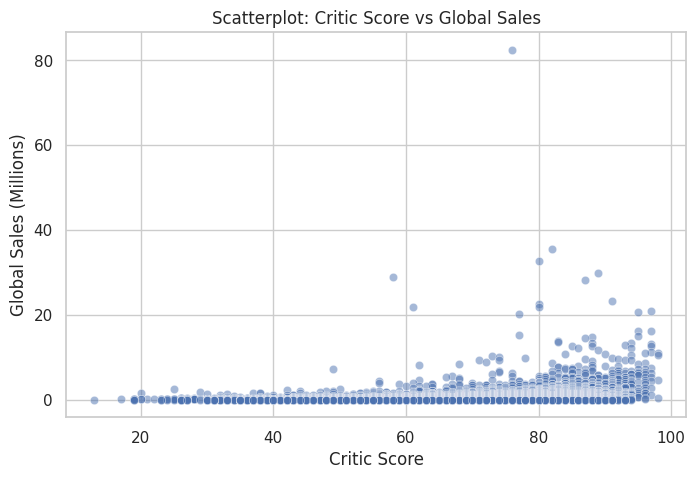

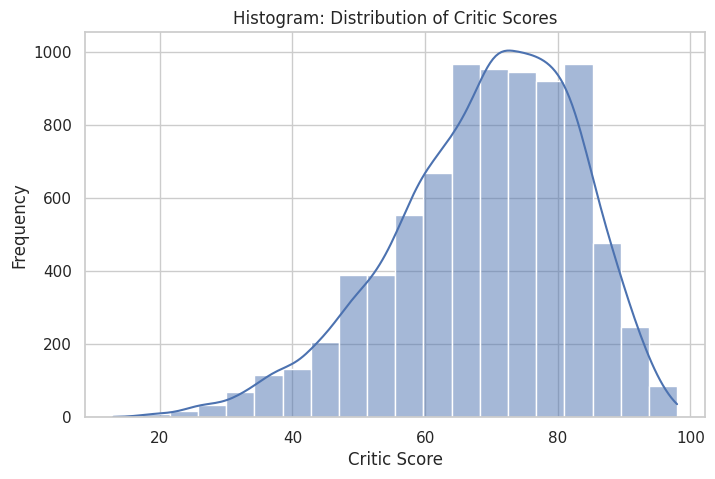

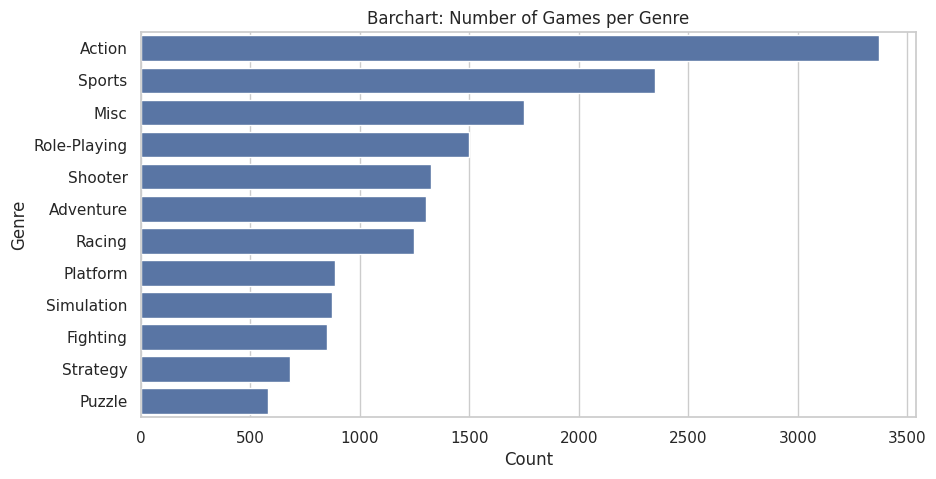

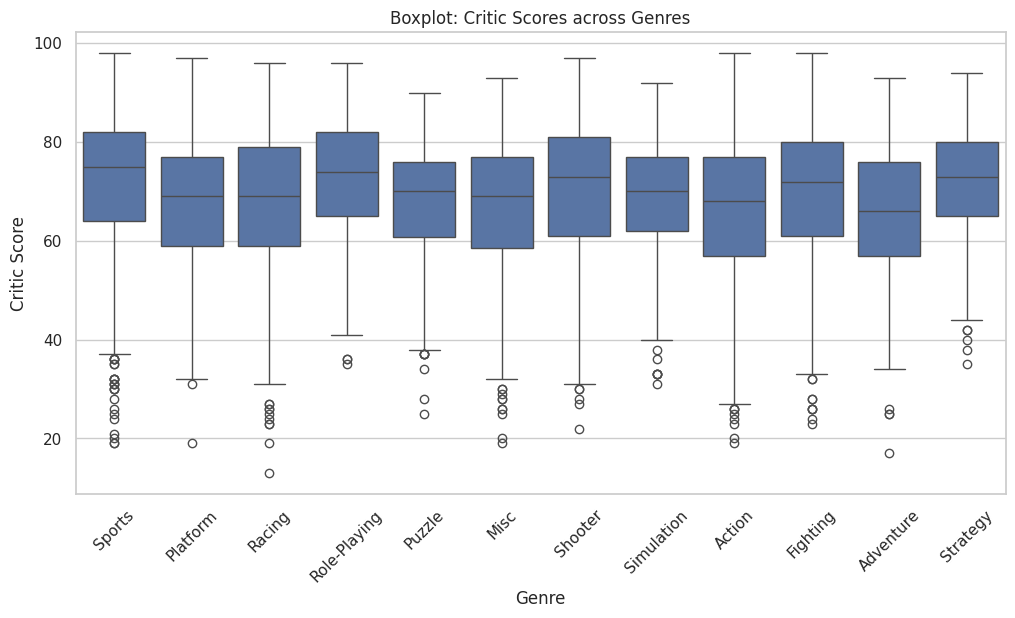

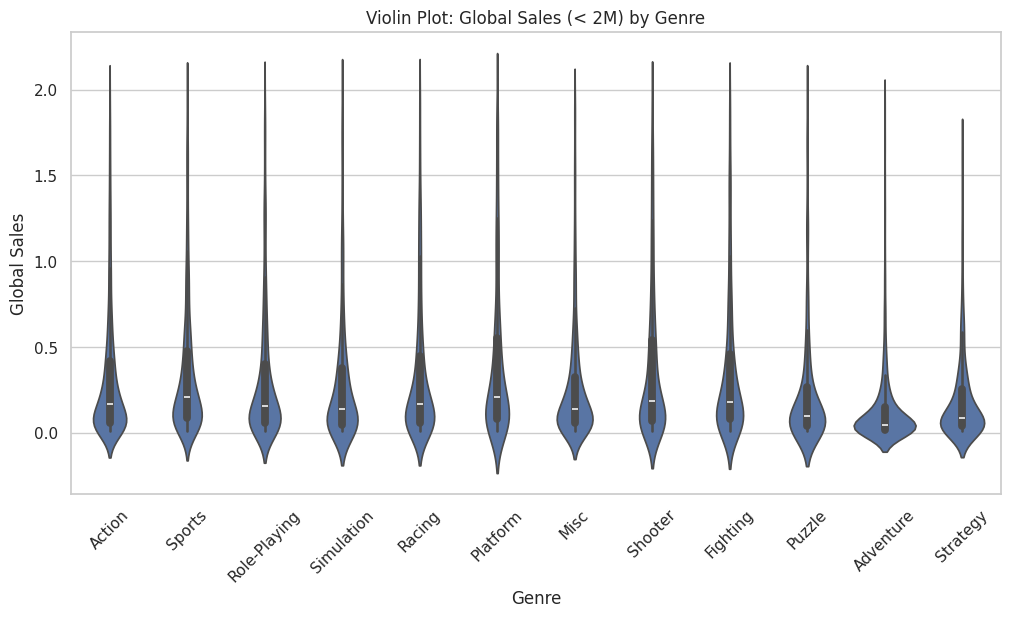

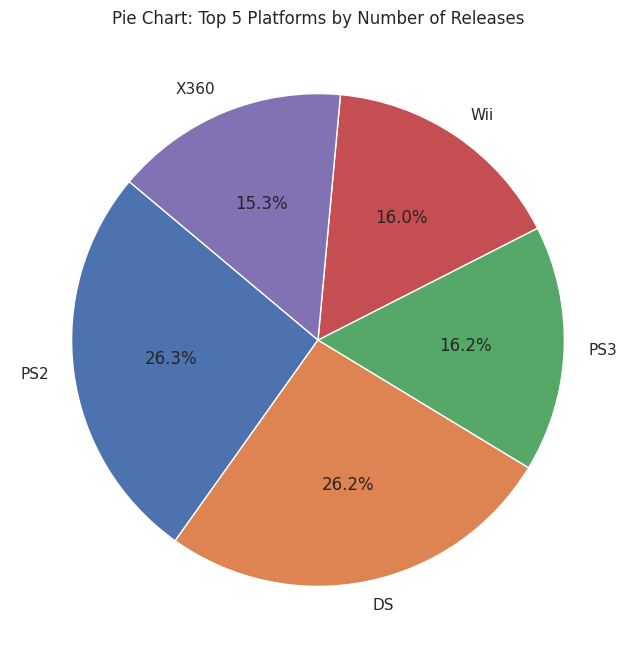

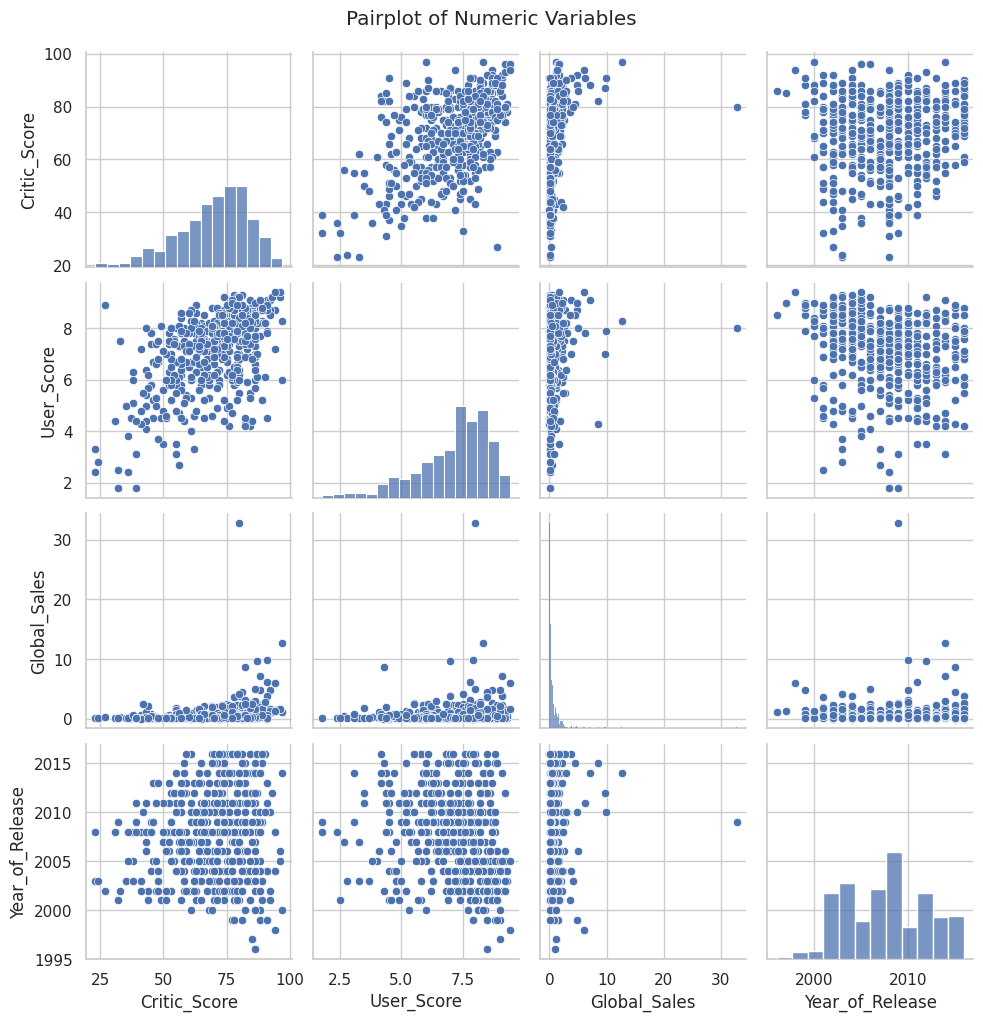

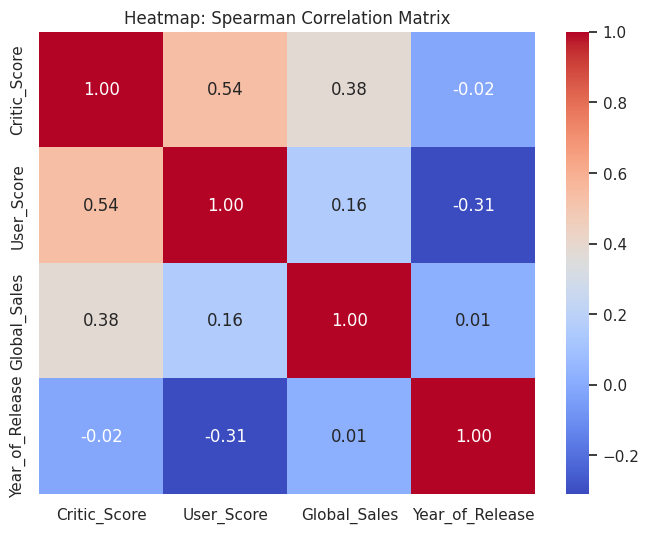

--- 7. Index Analysis ---
Is the index unique? True
Is the index time-based (DatetimeIndex)? False
Is the index sorted (monotonic increasing)? True

--- 9. Bonus: Engineering and Hypothesis Testing ---
New Engineered Features preview:
                       Name  Year_of_Release  Game_Age_Years  Global_Sales  \
0                Wii Sports           2006.0            10.0         82.53   
1         Super Mario Bros.           1985.0            31.0         40.24   
2            Mario Kart Wii           2008.0             8.0         35.52   
3         Wii Sports Resort           2009.0             7.0         32.77   
4  Pokemon Red/Pokemon Blue           1996.0            20.0         31.37   

   Is_Hit  
0       1  
1       1  
2       1  
3       1  
4       1  


T-Statistic: -2.1731
P-Value: 2.9887e-02
Conclusion: Reject the null hypothesis. There is a statistically significant difference in mean sales.


In [2]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Updated for Jupyter Notebook: Loading directly from the current directory
file_path = 'Video_Games_Sales_as_at_22_Dec_2016.csv'

# 3.1 Meta-Analysis: Checking file size
file_size_mb = os.path.getsize(file_path) / (1024 * 1024)
print(f"File size: {file_size_mb:.2f} MB\n")

# Loading the data into a DataFrame
df = pd.read_csv(file_path)

# 3.2 Data structure: Number of rows and columns
print(f"Shape of the dataset (Rows, Columns): {df.shape}\n")

# Data types and missing values
print("Data types and missing values:")
df.info()
print("\n")

# 4.1 Missing Values
print("--- Missing Values ---")
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Values': missing_data, 'Percentage (%)': missing_percent})
print(missing_df[missing_df['Missing Values'] > 0].sort_values(by='Percentage (%)', ascending=False))
print("\n")

# 4.2 Duplicates
print("--- Duplicates ---")
full_duplicates = df.duplicated().sum()
print(f"Full duplicates (exact row match): {full_duplicates}")

# Partial duplicates - e.g., the exact same game on the same platform
partial_duplicates = df.duplicated(subset=['Name', 'Platform']).sum()
print(f"Partial duplicates (same Name and Platform): {partial_duplicates}\n")

# 4.3 Suspicious Values
print("--- Suspicious Values ---")
print("Year of Release bounds:")
print(f"Min Year: {df['Year_of_Release'].min()}, Max Year: {df['Year_of_Release'].max()}")
print("\nChecking for 'tbd' (To Be Determined) in User_Score:")
tbd_count = (df['User_Score'] == 'tbd').sum()
print(f"Number of 'tbd' values: {tbd_count}\n")

# 4.4 Cardinality
print("--- Cardinality ---")
cardinality = df.nunique()
print(cardinality.sort_values())

# --- 5.1 Numeric Variables (Focusing on Global_Sales) ---
print("--- 5.1 Numeric Variables (Global_Sales) ---")
sales = df['Global_Sales'].dropna()

# Central metrics
mean_val = sales.mean()
median_val = sales.median()
std_val = sales.std()
min_val = sales.min()
max_val = sales.max()
q1 = sales.quantile(0.25)
q3 = sales.quantile(0.75)
iqr = q3 - q1
mad_val = (sales - median_val).abs().median()

print(f"Mean: {mean_val:.3f}, Median: {median_val:.3f}, Std: {std_val:.3f}")
print(f"Min: {min_val:.3f}, Max: {max_val:.3f}")
print(f"Q1 (25%): {q1:.3f}, Q3 (75%): {q3:.3f}, IQR: {iqr:.3f}, MAD: {mad_val:.3f}")

# Bias / Skewness
skewness = sales.skew()
print(f"Skewness: {skewness:.3f} (Positive = Right-skewed)")

# Outlier Detection
z_scores = (sales - mean_val) / std_val
outliers_z = sales[z_scores.abs() > 3]
outliers_iqr = sales[(sales < (q1 - 1.5 * iqr)) | (sales > (q3 + 1.5 * iqr))]
mod_z_scores = 0.6745 * (sales - median_val) / mad_val
outliers_mad = sales[mod_z_scores.abs() > 3.5]

print(f"\nOutliers detected by Z-Score: {len(outliers_z)}")
print(f"Outliers detected by IQR: {len(outliers_iqr)}")
print(f"Outliers detected by Modified Z-Score (MAD): {len(outliers_mad)}\n")


# --- 5.2 Categorical Variables (Focusing on Genre) ---
print("--- 5.2 Categorical Variables (Genre) ---")
genre = df['Genre'].dropna()
total_count = genre.count()

# Frequencies and Mode
frequencies = genre.value_counts()
mode_val = frequencies.index[0]
mode_pct = (frequencies.iloc[0] / total_count) * 100
print(f"Mode (Most frequent): {mode_val} ({mode_pct:.2f}% of data)")

# Top K (Let's choose K=3)
k = 3
top_k = frequencies.head(k)
top_k_pct = (top_k.sum() / total_count) * 100
print(f"Top {k} genres hold {top_k_pct:.2f}% of the data.")

# Minimum values for P% (Let's choose P=80%)
p = 80
cumulative_pct = (frequencies / total_count * 100).cumsum()
min_values_p = cumulative_pct[cumulative_pct <= p].index.tolist()
if len(min_values_p) < len(frequencies):
    min_values_p.append(cumulative_pct[cumulative_pct > p].index[0])

print(f"Minimum categories to represent {p}% of data: {len(min_values_p)} categories")
print(f"These categories are: {min_values_p}")

# Rare categories (less than 2% of the data)
rare_categories = frequencies[frequencies / total_count < 0.02]
print(f"Rare categories (under 2%): {rare_categories.index.tolist()}")

# Pre-processing: Convert User_Score to numeric, turning 'tbd' into NaN
df['User_Score'] = pd.to_numeric(df['User_Score'], errors='coerce')

# --- 6.1 Numeric-Numeric Correlations ---
print("--- 6.1 Numeric Correlations ---")
numeric_cols = ['Critic_Score', 'User_Score', 'Global_Sales', 'Year_of_Release']
num_df = df[numeric_cols].dropna()

print("Pearson Correlation:\n", num_df.corr(method='pearson'), "\n")
print("Spearman Correlation:\n", num_df.corr(method='spearman'), "\n")
print("Kendall Correlation:\n", num_df.corr(method='kendall'), "\n")

# --- 6.2 Categorical-Categorical & Categorical-Numeric (Binning) ---
print("--- 6.2 Binning and Relationships ---")
df['Sales_Category'] = pd.qcut(df['Global_Sales'], q=3, labels=['Low', 'Medium', 'High'])
crosstab_genre_sales = pd.crosstab(df['Genre'], df['Sales_Category'])
print("Cross-tabulation (Genre vs Sales Category):\n", crosstab_genre_sales, "\n")

# --- 6.3 Graphs ---
sns.set_theme(style="whitegrid")

# 1. Scatterplot
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Critic_Score', y='Global_Sales', alpha=0.5)
plt.title('Scatterplot: Critic Score vs Global Sales')
plt.xlabel('Critic Score')
plt.ylabel('Global Sales (Millions)')
plt.show()

# 2. Histogram
plt.figure(figsize=(8, 5))
sns.histplot(df['Critic_Score'].dropna(), bins=20, kde=True)
plt.title('Histogram: Distribution of Critic Scores')
plt.xlabel('Critic Score')
plt.ylabel('Frequency')
plt.show()

# 3. Barchart
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='Genre', order=df['Genre'].value_counts().index)
plt.title('Barchart: Number of Games per Genre')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

# 4. Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Genre', y='Critic_Score')
plt.title('Boxplot: Critic Scores across Genres')
plt.xticks(rotation=45)
plt.xlabel('Genre')
plt.ylabel('Critic Score')
plt.show()

# 5. Violin Plot (Filtered to sales < 2M for better visibility)
plt.figure(figsize=(12, 6))
sns.violinplot(data=df[df['Global_Sales'] < 2], x='Genre', y='Global_Sales')
plt.title('Violin Plot: Global Sales (< 2M) by Genre')
plt.xticks(rotation=45)
plt.xlabel('Genre')
plt.ylabel('Global Sales')
plt.show()

# 6. Pie Chart
plt.figure(figsize=(8, 8))
platform_counts = df['Platform'].value_counts().head(5)
plt.pie(platform_counts, labels=platform_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Pie Chart: Top 5 Platforms by Number of Releases')
plt.show()

# 7. Pairplot
sns.pairplot(num_df.sample(500))
plt.suptitle('Pairplot of Numeric Variables', y=1.02)
plt.show()

# 8. Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(num_df.corr(method='spearman'), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap: Spearman Correlation Matrix')
plt.show()

# --- 7. Index Analysis ---
print("--- 7. Index Analysis ---")

# Is the index unique?
is_unique = df.index.is_unique
print(f"Is the index unique? {is_unique}")

# Is the index time-based?
is_time_based = isinstance(df.index, pd.DatetimeIndex)
print(f"Is the index time-based (DatetimeIndex)? {is_time_based}")

# Is the index sorted?
is_sorted = df.index.is_monotonic_increasing
print(f"Is the index sorted (monotonic increasing)? {is_sorted}\n")

print("--- 9. Bonus: Engineering and Hypothesis Testing ---")

# Feature Engineering 1: Age of the game
df['Game_Age_Years'] = 2016 - df['Year_of_Release']

# Feature Engineering 2: Binary target for Classification models
df['Is_Hit'] = (df['Global_Sales'] > 1.0).astype(int)

print("New Engineered Features preview:")
print(df[['Name', 'Year_of_Release', 'Game_Age_Years', 'Global_Sales', 'Is_Hit']].head())
print("\n")

# Hypothesis Testing: Independent T-Test
action_sales = df[df['Genre'] == 'Action']['Global_Sales'].dropna()
rpg_sales = df[df['Genre'] == 'Role-Playing']['Global_Sales'].dropna()

t_stat, p_value = stats.ttest_ind(action_sales, rpg_sales, equal_var=False)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4e}")
if p_value < 0.05:
    print("Conclusion: Reject the null hypothesis. There is a statistically significant difference in mean sales.")
else:
    print("Conclusion: Fail to reject the null hypothesis. No significant difference in mean sales.")